# Prévision de la consommation électrique nationale à 24h (RTE)

Ce notebook entraîne et compare, via MLflow, 3 modèles de prévision de la consommation électrique
française à un horizon **fixe de 24h** (cas de prévision day-ahead classique), à partir de
`data/training_dataset_2022_2025.csv` (consommation horaire RTE 2022-2025 + météo nationale
agrégée, construit par `etl/build-training-dataset.py`).

**Stratégie retenue** : chaque modèle prédit directement `consumption(t0 + 24h)` à partir de
features connues à l'origine t0, sans récursion. Horizon fixé à 24h uniquement (pas de feature
`horizon_h` ni de boucle multi-horizon) — allège les calculs et les graphes, et rend les résultats
directement comparables au notebook Prophet (`train_timeseries_models.ipynb`), qui évalue lui aussi
des prévisions à 24h.

**Limitation à garder en tête dès maintenant** : faute de prévisions météo archivées, la feature de
température à l'heure cible (`temp_target`) utilise la météo **réelle** — un proxy optimiste pour une
vraie prévision météo qui serait, elle, imparfaite en déploiement réel. Détaillé plus loin dans le
notebook.

MLflow tourne ici en local (backend SQLite `../mlflow.db`, pas de serveur distant) — suffisant pour
ce projet de certification, sans infra cloud existante.


## 1. Imports

In [1]:
# Librairies de base pour la manipulation de données et le calcul numérique
import numpy as np
import pandas as pd

# Jours fériés français, pour la feature calendaire target_is_holiday
import holidays

# Modèles de régression : un modèle linéaire (baseline), un ensemble d'arbres (Random Forest)
# et un modèle de gradient boosting (XGBoost), les 3 candidats retenus pour cette comparaison
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_absolute_error,
    root_mean_squared_error,
)
from xgboost import XGBRegressor

# MLflow pour tracker les hyperparamètres, les métriques et les modèles entraînés
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.models import infer_signature

# Pour le graphe de comparaison MAPE / horizon en fin de notebook
import matplotlib.pyplot as plt


## 2. Configuration

In [2]:
# Chemin du dataset final construit par etl/build-training-dataset.py (chemin relatif au dossier training/)
DATA_PATH = "../data/training_dataset_2022_2025.csv"

# Horizon de prévision fixe : uniquement le cas "prévision à 24h" (jour suivant), pour rester
# léger et directement comparable aux notebooks Prophet
TARGET_HORIZON_H = 24

# Décalages (en heures) utilisés pour construire les features de lag de consommation à l'origine t0
LAGS = [1, 24, 48, 168]  # 1h, 1 jour, 2 jours, 1 semaine avant t0

# Coupure temporelle du split train/test : tout ce qui vise une cible avant 2025 sert à l'entraînement,
# le reste (année 2025 complète) sert de test
TEST_CUTOFF = pd.Timestamp("2025-01-01T00:00:00+00:00")

# Tracking MLflow en local (pas de serveur distant). MLflow 3.x a mis en maintenance le backend
# fichier brut ("file:../mlruns") au profit d'un backend SQLite — reste 100% local, juste un
# fichier .db à la racine du repo au lieu de fichiers plats.
MLFLOW_TRACKING_URI = "sqlite:///../mlflow.db"
EXPERIMENT_NAME = "rte-consumption-forecast"

# Pour les courbes "prévisions vs réel" affichées après chaque modèle : deux fenêtres de 2 semaines
# (hiver / été) pour comparer le comportement du modèle selon la saison. Bornes modifiables
# manuellement ici si besoin.
PLOT_WINDOWS = {
    "hiver": (pd.Timestamp("2025-01-06T00:00:00+00:00"), pd.Timestamp("2025-01-20T00:00:00+00:00")),
    "été": (pd.Timestamp("2025-07-07T00:00:00+00:00"), pd.Timestamp("2025-07-21T00:00:00+00:00")),
}


## 3. Chargement des données brutes

In [3]:
# Chargement du dataset final : une ligne par heure, consommation nationale + météo agrégée
hourly = pd.read_csv(DATA_PATH, parse_dates=["datetime_utc"])
hourly = hourly.set_index("datetime_utc").sort_index()

print(f"{len(hourly)} lignes, de {hourly.index.min()} à {hourly.index.max()}")

# NB : la version 2021-2025 de ce dataset avait quelques heures manquantes (une par an, à 23h heure
# locale le jour du passage à l'heure d'hiver — artefact de l'API RTE qui renvoie 48 points/jour,
# ces jours-là en comptent 25). Ce n'était PAS un artefact de l'heure ambiguë (02h-03h, dédoublée
# deux fois avec des offsets distincts, correctement gérée par RTE) mais un vrai trou, isolé, à un
# autre moment de la journée. Vérifié : cette version 2022-2025 n'a, elle, aucune heure manquante
# (contrôlé ci-dessous dynamiquement). Dans tous les cas, les lags/rolling/horizons sont calculés
# par lookup sur timestamp exact (pas par décalage de ligne .shift()) pour rester robustes à
# d'éventuels trous futurs sans désaligner silencieusement les lignes suivantes.
expected_full_range = pd.date_range(hourly.index.min(), hourly.index.max(), freq="h")
print(f"Heures manquantes dans la série : {len(expected_full_range) - len(hourly)}")


35064 lignes, de 2021-12-31 23:00:00+00:00 à 2025-12-31 22:00:00+00:00
Heures manquantes dans la série : 0


## 4. Feature engineering à l'origine (t0)

In [4]:
def lag_by_timestamp(series: pd.Series, hours: int) -> np.ndarray:
    """Valeur de `series` exactement `hours` heures avant chaque timestamp de son index.
    Lookup par timestamp (et non un .shift() positionnel) pour que les 5 heures manquantes
    de la série ne désalignent pas silencieusement les valeurs suivantes."""
    target_ts = series.index - pd.Timedelta(hours, unit="h")  # unit explicite : évite le
    # DeprecationWarning numpy sur les Timedelta construits via un mot-clé (hours=...)
    return series.reindex(target_ts).to_numpy()


# Lags de consommation connus à l'origine t0
for lag_h in LAGS:
    hourly[f"consumption_lag_{lag_h}"] = lag_by_timestamp(hourly["consumption"], lag_h)

# Stats glissantes se terminant à t0, calculées sur une fenêtre TEMPORELLE (pas un nombre de lignes)
# via .rolling("24h"), pour rester correctes malgré les 5 heures manquantes de la série
hourly["rolling_mean_24h"] = hourly["consumption"].rolling("24h").mean()
hourly["rolling_std_24h"] = hourly["consumption"].rolling("24h").std()
hourly["rolling_mean_168h"] = hourly["consumption"].rolling("168h").mean()

# Température réelle à l'origine : légitimement connue au moment de la prévision (pas un proxy)
hourly["temp_t0"] = hourly["temperature_weighted_mean"]

ORIGIN_FEATURE_COLUMNS = [f"consumption_lag_{h}" for h in LAGS] + [
    "rolling_mean_24h", "rolling_std_24h", "rolling_mean_168h", "temp_t0",
]
hourly[ORIGIN_FEATURE_COLUMNS].describe()


,consumption_lag_1,consumption_lag_24,consumption_lag_48,consumption_lag_168,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,temp_t0
count,35063.000000,35040.000000,35016.000000,34896.000000,35064.000000,35063.000000,35064.000000,35064.000000
mean,50320.527607,50307.582720,50294.775246,50245.929175,50314.251725,4548.758122,50285.407088,13.420672
std,10612.730818,10603.723518,10595.472557,10577.604707,9593.206108,816.905964,9060.184371,6.949880
min,30040.500000,30040.500000,30040.500000,30040.500000,35585.354167,735.744606,38808.395833,-3.880000
25%,42496.500000,42491.500000,42485.250000,42461.375000,43561.895833,3945.056603,42858.316220,8.350000
50%,48565.000000,48558.250000,48551.750000,48507.250000,46797.177083,4632.840609,45986.693452,12.970000
75%,57091.000000,57064.875000,57043.000000,56924.875000,57304.989583,5107.800650,57516.446429,18.380000
max,87315.000000,87315.000000,87315.000000,87315.000000,78425.229167,8329.593702,74994.380952,35.970000


## 5. Construction de la table supervisée (horizon fixe 24h)


In [5]:
# Une seule cible par origine (horizon fixé à TARGET_HORIZON_H=24h) : plus besoin de boucle
# multi-horizon, juste un lookup timestamp (t0 + 24h) sur la série horaire brute pour la cible et
# la température cible — 24x moins de lignes que l'approche multi-horizon, donc plus rapide à tout
# calculer et entraîner
supervised_df = hourly[ORIGIN_FEATURE_COLUMNS].copy()
supervised_df.index.name = "origin_datetime_utc"
supervised_df["target_datetime_utc"] = supervised_df.index + pd.Timedelta(TARGET_HORIZON_H, unit="h")
supervised_df["target_consumption"] = hourly["consumption"].reindex(supervised_df["target_datetime_utc"]).to_numpy()
supervised_df["temp_target"] = hourly["temperature_weighted_mean"].reindex(supervised_df["target_datetime_utc"]).to_numpy()
supervised_df = supervised_df.reset_index()

print(f"Table supervisée (horizon {TARGET_HORIZON_H}h) : {supervised_df.shape[0]} lignes, {supervised_df.shape[1]} colonnes")


Table supervisée (horizon 24h) : 35064 lignes, 12 colonnes


## 6. Features calendaires sur l'horizon cible + température cible

Les features calendaires (heure, jour de semaine, mois, jour férié) sont calculées sur le
**timestamp cible** (`target_datetime_utc`), pas sur l'origine — c'est le contexte calendaire de
l'heure qu'on cherche à prédire qui pilote la consommation (ex: pic vers 19h, creux le week-end et
les jours fériés), pas celui de l'origine. Ce sont de simples calculs de calendrier, connus à
l'avance, donc légitimes.

**Limitation importante à garder en tête** : `temp_target` utilise la température **réelle**
mesurée à l'heure cible, faute de prévisions météo archivées dans ce dataset. En déploiement réel,
seule une *prévision* météo (imparfaite) serait disponible à l'heure de la prédiction — cette
feature fuit donc de l'information future et rend l'évaluation hors-ligne optimiste par rapport
à un vrai déploiement. Corriger ce point (récupérer des prévisions météo archivées) est hors
scope ici, mais à garder en tête pour la suite.


In [6]:
# Conversion du timestamp cible en heure locale française (même logique que `local_hour`
# dans etl/build-training-dataset.py), car la consommation suit le rythme de vie local, pas l'UTC
target_local = supervised_df["target_datetime_utc"].dt.tz_convert("Europe/Paris")

supervised_df["target_local_hour"] = target_local.dt.hour
supervised_df["target_day_of_week"] = target_local.dt.dayofweek  # 0=lundi ... 6=dimanche
supervised_df["target_month"] = target_local.dt.month
supervised_df["target_is_weekend"] = supervised_df["target_day_of_week"].isin([5, 6]).astype(int)

# Jours fériés français (bibliothèque `holidays`) : la consommation électrique chute nettement les
# jours fériés (usines/bureaux fermés), un signal que les seules features heure/jour/mois ne
# captent pas. Calculé sur la date locale française du timestamp CIBLE (couvre toutes les années
# présentes dans les cibles, avec une marge d'un an de chaque côté).
fr_holidays = holidays.France(years=range(target_local.dt.year.min() - 1, target_local.dt.year.max() + 2))
supervised_df["target_is_holiday"] = target_local.dt.date.isin(fr_holidays).astype(int)

# Encodages cycliques (sin/cos) : indispensables pour la régression linéaire, qui sans ça verrait
# 23h et 0h comme deux valeurs éloignées alors qu'elles sont adjacentes. Sans effet négatif sur
# les modèles à base d'arbres, donc calculés une seule fois et réutilisés pour les 3 modèles.
for col, short_name, period in [
    ("target_local_hour", "hour", 24),
    ("target_day_of_week", "dow", 7),
    ("target_month", "month", 12),
]:
    angle = 2 * np.pi * supervised_df[col] / period
    supervised_df[f"target_{short_name}_sin"] = np.sin(angle)
    supervised_df[f"target_{short_name}_cos"] = np.cos(angle)


## 7. Nettoyage et liste finale des features

In [7]:
FEATURE_COLUMNS = ORIGIN_FEATURE_COLUMNS + [
    "temp_target",
    "target_local_hour", "target_day_of_week", "target_month", "target_is_weekend", "target_is_holiday",
    "target_hour_sin", "target_hour_cos",
    "target_dow_sin", "target_dow_cos",
    "target_month_sin", "target_month_cos",
]

n_before = len(supervised_df)
model_df = supervised_df.dropna(subset=FEATURE_COLUMNS + ["target_consumption"]).reset_index(drop=True)
n_after = len(model_df)
print(
    f"{n_before - n_after} lignes supprimées pour valeurs manquantes "
    "(débuts de série pour les lags longs + quelques cibles tombant sur les 5 heures manquantes)"
)
print(f"Table finale : {n_after} lignes")


192 lignes supprimées pour valeurs manquantes (débuts de série pour les lags longs + quelques cibles tombant sur les 5 heures manquantes)
Table finale : 34872 lignes


## 8. Split train/test temporel

In [8]:
train_df = model_df[model_df["target_datetime_utc"] < TEST_CUTOFF].copy()
test_df = model_df[model_df["target_datetime_utc"] >= TEST_CUTOFF].copy()

# Split sur le timestamp CIBLE (pas sur l'origine t0) : une origine fin décembre 2024 avec un
# horizon de 24h vise une cible en janvier 2025. Découper sur t0 ferait fuiter cette valeur réelle
# de 2025 dans les labels d'entraînement. Découper sur la cible garantit qu'aucun actual 2025
# n'apparaît jamais comme label de train, tout en laissant les lags du test set référencer
# légitimement des actuals de fin 2024 (normal à l'inférence réelle).
X_train, y_train = train_df[FEATURE_COLUMNS], train_df["target_consumption"]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df["target_consumption"]

print(f"Train : {len(train_df)} lignes, cibles de {train_df['target_datetime_utc'].min()} à {train_df['target_datetime_utc'].max()}")
print(f"Test  : {len(test_df)} lignes, cibles de {test_df['target_datetime_utc'].min()} à {test_df['target_datetime_utc'].max()}")


Train : 26113 lignes, cibles de 2022-01-08 23:00:00+00:00 à 2024-12-31 23:00:00+00:00
Test  : 8759 lignes, cibles de 2025-01-01 00:00:00+00:00 à 2025-12-31 22:00:00+00:00


## 9. Setup MLflow

In [9]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

results = []


def evaluate_and_log(run_name, y_true, y_pred, params, model=None, log_model_fn=None):
    """Calcule MAPE/RMSE/MAE, les logge dans un run MLflow dédié, et logge le modèle fitté si
    fourni. Retourne un résumé pour le tableau comparatif final (section 14)."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({"dataset_version": "2022_2025", "horizon_strategy": "single_24h"})
        mlflow.log_params(params)

        mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # en %
        rmse = root_mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        mlflow.log_metric("test_mape", mape)
        mlflow.log_metric("test_rmse", rmse)
        mlflow.log_metric("test_mae", mae)

        if model is not None and log_model_fn is not None:
            # Cast en float64 : FEATURE_COLUMNS mélange int (target_day_of_week, target_month,
            # target_is_weekend, target_is_holiday) et float. MLflow déconseille les colonnes int
            # dans la signature (elles ne peuvent pas représenter de valeurs manquantes) -> on
            # suit sa propre recommandation en déclarant tout en float64 pour l'exemple d'entrée
            # et la signature loggués.
            sample = X_train.head(100).astype("float64")
            signature = infer_signature(sample, model.predict(sample))
            log_model_fn(model, name="model", signature=signature, input_example=sample.head(5))

    summary = {"run_name": run_name, "mape": mape, "rmse": rmse, "mae": mae}
    results.append(summary)
    return summary


## 9bis. Fonction utilitaire : courbe prévisions vs réel

Après chaque modèle, on affiche deux courbes temporelles — une sur une fenêtre de 2 semaines en
hiver, une sur 2 semaines en été (`PLOT_WINDOWS`, définies en configuration) — avec la consommation
réelle superposée à la prévision à 24h. Un seul horizon désormais (voir section 2), donc un simple
graphe à 2 courbes (réel vs prédiction), comme dans les notebooks Prophet — MAPE affiché dans le
titre.


In [10]:
def plot_forecast_vs_actual(model_name, window_label, window_start, window_end, target_dt, y_true, y_pred):
    """Courbe temporelle à 2 courbes : consommation réelle vs prévision à 24h, sur une fenêtre
    temporelle donnée (ex: 2 semaines d'hiver ou d'été). MAPE affiché dans le titre."""
    plot_df = pd.DataFrame({
        "target_datetime_utc": pd.to_datetime(np.asarray(target_dt)),
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
    })
    plot_df = plot_df[
        (plot_df["target_datetime_utc"] >= window_start) & (plot_df["target_datetime_utc"] < window_end)
    ].sort_values("target_datetime_utc")

    mape = mean_absolute_percentage_error(plot_df["y_true"], plot_df["y_pred"]) * 100

    plt.figure(figsize=(14, 5))
    plt.plot(plot_df["target_datetime_utc"], plot_df["y_true"], label="Consommation réelle", color="black", linewidth=2)
    plt.plot(
        plot_df["target_datetime_utc"], plot_df["y_pred"], label="Prévision (24h)",
        color="tab:blue", linestyle="--",
    )
    plt.xlabel("Date")
    plt.ylabel("Consommation (MW)")
    plt.title(f"{model_name} — prévisions vs réel ({window_label}) — MAPE={mape:.2f}%")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 10. Baseline naïve (persistance J-1)

In [11]:
# Baseline naïve de persistance : on prédit la consommation cible par la valeur réelle observée
# 24h avant l'heure cible — comme l'horizon est désormais fixé à 24h, ça revient exactement à
# prédire par la valeur réelle à l'origine t0. Sert de repère pour juger si les modèles apportent
# une vraie valeur ajoutée par rapport à "rien ne change d'un jour à l'autre"
naive_reference_ts = test_df["target_datetime_utc"] - pd.Timedelta(24, unit="h")
y_pred_naive = hourly["consumption"].reindex(naive_reference_ts).to_numpy()

# Quelques valeurs de référence peuvent tomber sur une des 5 heures manquantes de la source RTE :
# on les exclut de l'évaluation de cette baseline (impact marginal)
valid_mask = ~np.isnan(y_pred_naive)
print(f"Baseline naïve : {(~valid_mask).sum()} lignes exclues (référence tombant sur une heure manquante)")

result_naive = evaluate_and_log(
    run_name="naive_persistence_baseline",
    y_true=y_test.to_numpy()[valid_mask],
    y_pred=y_pred_naive[valid_mask],
    params={"method": "persistence", "reference_offset_hours": 24},
)
result_naive


Baseline naïve : 0 lignes exclues (référence tombant sur une heure manquante)


{'run_name': 'naive_persistence_baseline',
 'mape': 5.104482705933326,
 'rmse': 3665.2770798960387,
 'mae': 2540.2380979563877}

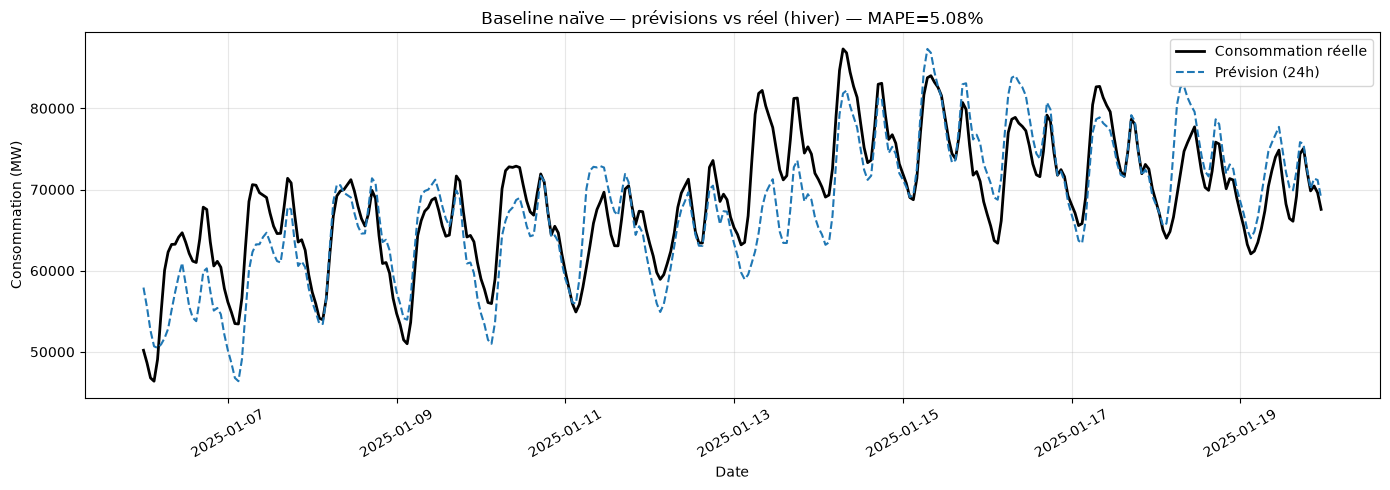

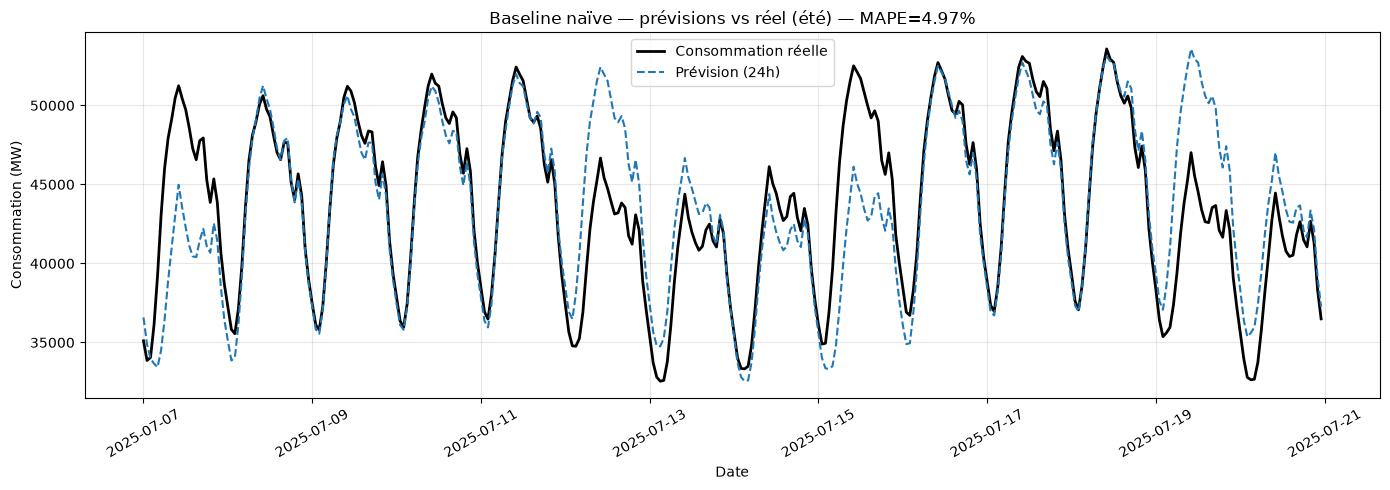

In [12]:
for window_label, (window_start, window_end) in PLOT_WINDOWS.items():
    plot_forecast_vs_actual(
        "Baseline naïve", window_label, window_start, window_end,
        test_df["target_datetime_utc"].to_numpy()[valid_mask],
        y_test.to_numpy()[valid_mask],
        y_pred_naive[valid_mask],
    )


## 11. Régression Linéaire

In [13]:
lr_params = {"model": "LinearRegression", "preprocessing": "StandardScaler"}
lr_model = make_pipeline(StandardScaler(), LinearRegression())
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

result_lr = evaluate_and_log(
    run_name="linear_regression",
    y_true=y_test,
    y_pred=y_pred_lr,
    params=lr_params,
    model=lr_model,
    log_model_fn=mlflow.sklearn.log_model,
)
result_lr


{'run_name': 'linear_regression',
 'mape': 4.17225393929053,
 'rmse': 2622.1715975355664,
 'mae': 2054.715278122505}

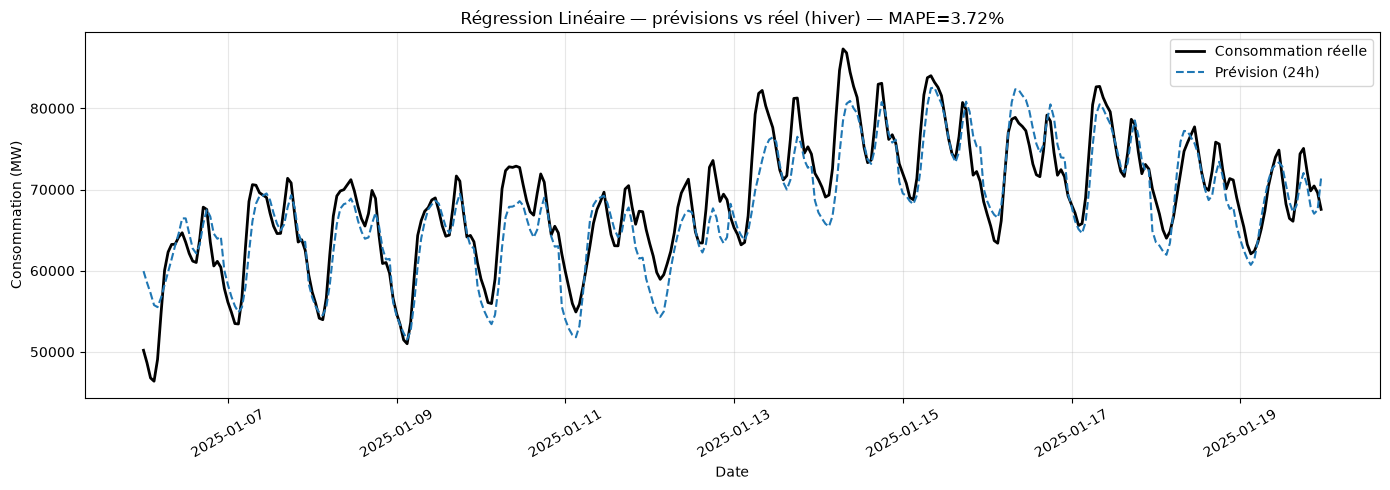

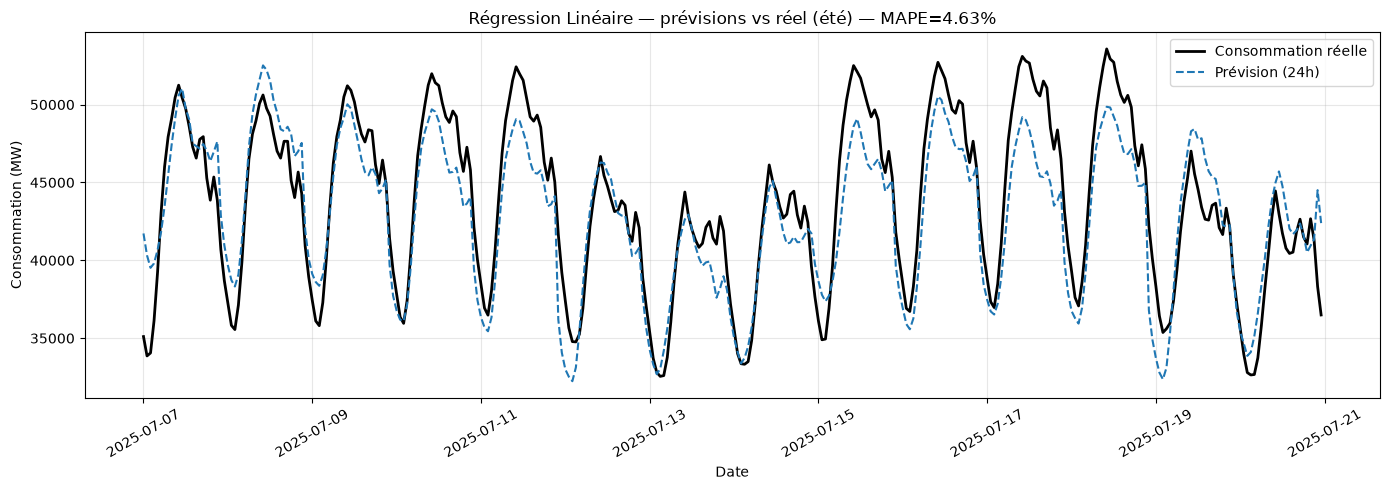

In [14]:
for window_label, (window_start, window_end) in PLOT_WINDOWS.items():
    plot_forecast_vs_actual(
        "Régression Linéaire", window_label, window_start, window_end,
        test_df["target_datetime_utc"], y_test, y_pred_lr,
    )


## 12. Random Forest

In [15]:
rf_params = {"model": "RandomForestRegressor", "n_estimators": 150, "max_depth": 16, "n_jobs": -1, "random_state": 42}
rf_model = RandomForestRegressor(
    n_estimators=rf_params["n_estimators"],
    max_depth=rf_params["max_depth"],
    n_jobs=rf_params["n_jobs"],
    random_state=rf_params["random_state"],
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

result_rf = evaluate_and_log(
    run_name="random_forest",
    y_true=y_test,
    y_pred=y_pred_rf,
    params=rf_params,
    model=rf_model,
    log_model_fn=mlflow.sklearn.log_model,
)
result_rf


{'run_name': 'random_forest',
 'mape': 2.0970031306476185,
 'rmse': 1571.1881432752275,
 'mae': 1086.7808540965725}

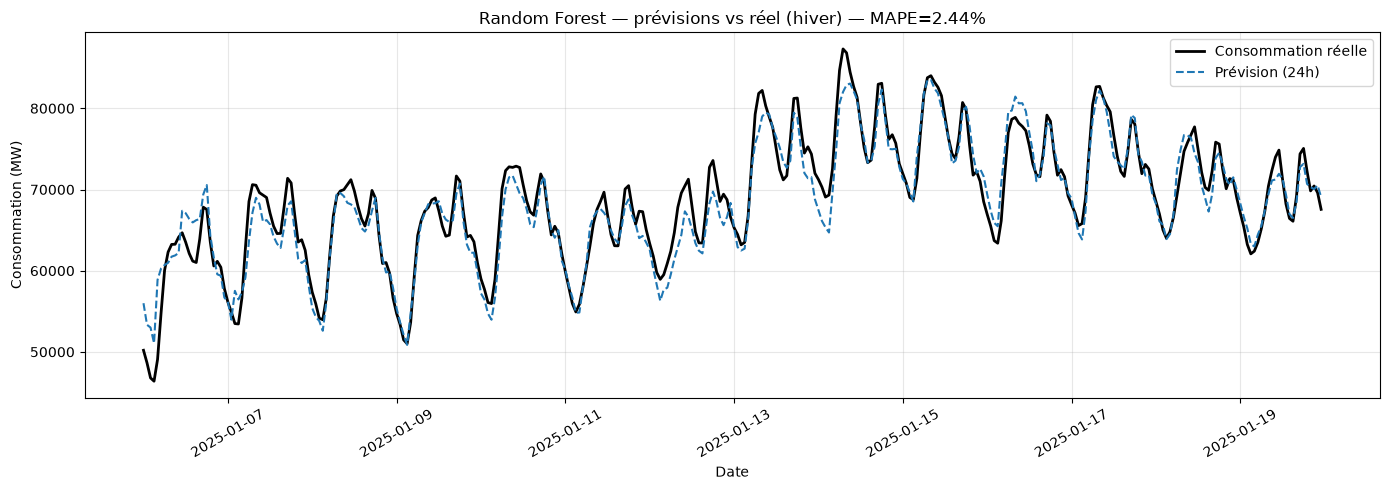

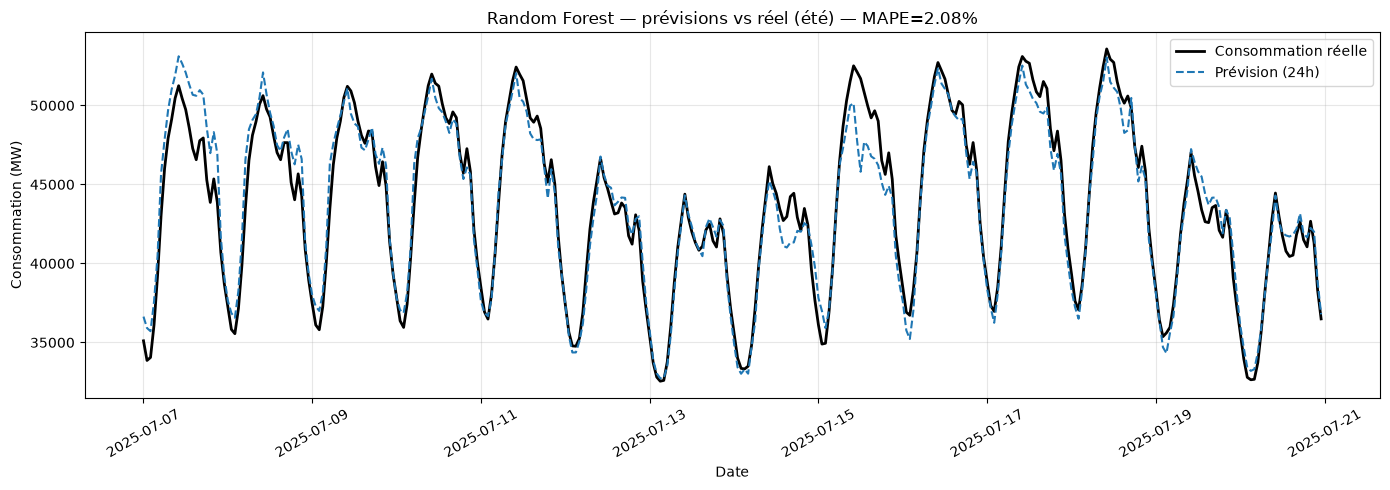

In [16]:
for window_label, (window_start, window_end) in PLOT_WINDOWS.items():
    plot_forecast_vs_actual(
        "Random Forest", window_label, window_start, window_end,
        test_df["target_datetime_utc"], y_test, y_pred_rf,
    )


## 13. XGBoost

In [17]:
xgb_params = {
    "model": "XGBRegressor",
    "n_estimators": 400,
    "max_depth": 7,
    "learning_rate": 0.08,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "random_state": 42,
    "objective": "reg:squarederror",
}
xgb_model = XGBRegressor(**{k: v for k, v in xgb_params.items() if k != "model"})
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

result_xgb = evaluate_and_log(
    run_name="xgboost",
    y_true=y_test,
    y_pred=y_pred_xgb,
    params=xgb_params,
    model=xgb_model,
    log_model_fn=mlflow.xgboost.log_model,
)
result_xgb


{'run_name': 'xgboost',
 'mape': 1.7712266735208217,
 'rmse': 1290.0313413668493,
 'mae': 916.5580688434753}

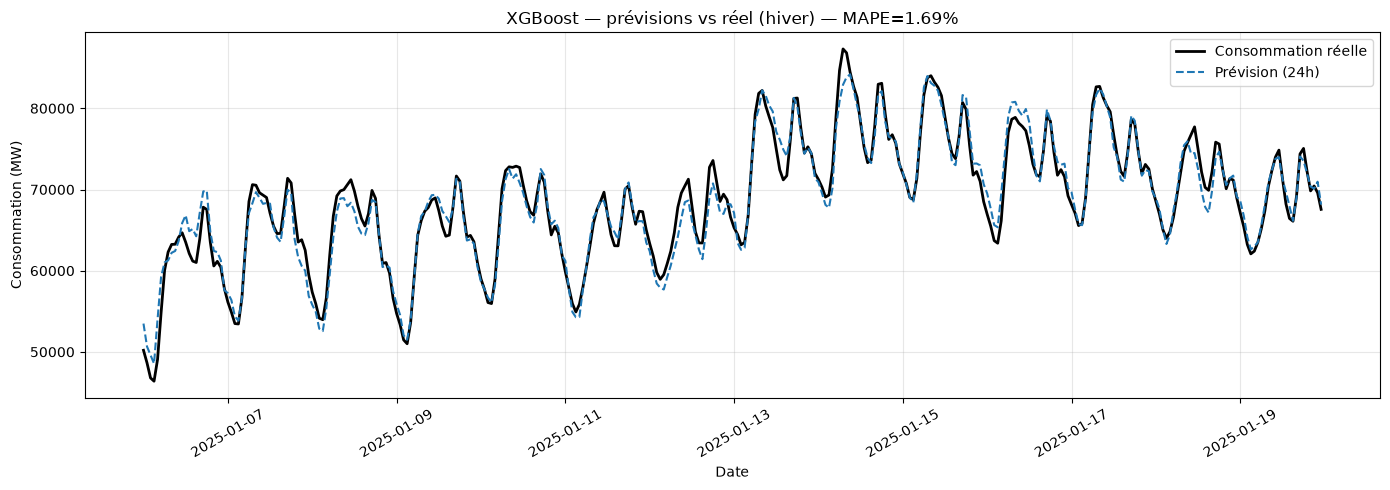

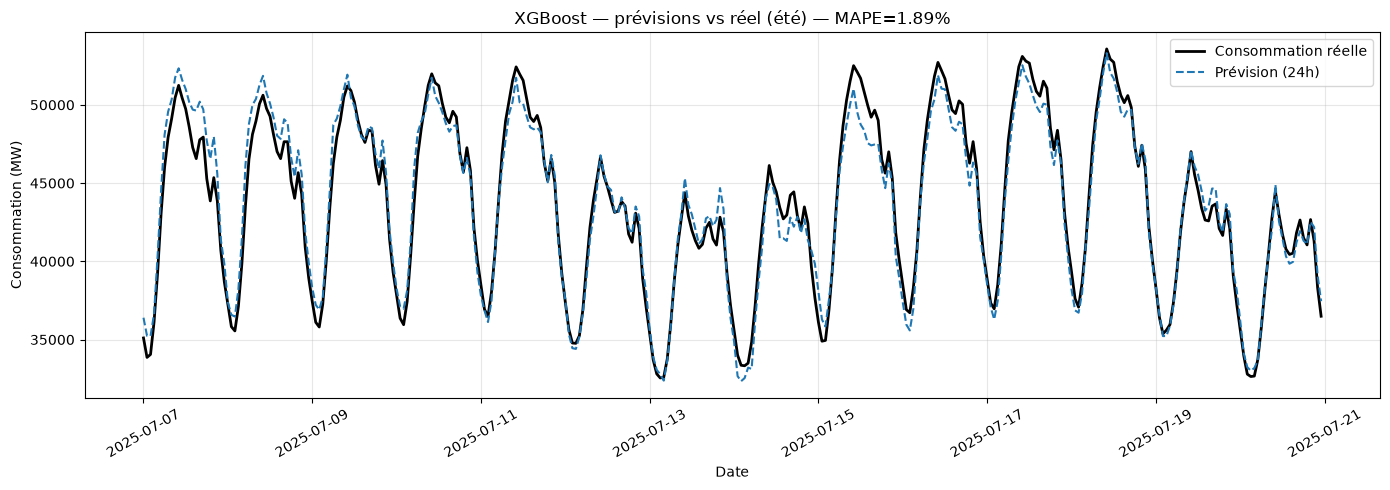

In [18]:
for window_label, (window_start, window_end) in PLOT_WINDOWS.items():
    plot_forecast_vs_actual(
        "XGBoost", window_label, window_start, window_end,
        test_df["target_datetime_utc"], y_test, y_pred_xgb,
    )


## 13bis. Recherche d'hyperparamètres XGBoost (random search + early stopping)

Fine-tuning "rapide" du meilleur modèle (XGBoost, MAPE 1.74% avec les hyperparamètres par défaut) :
échantillonnage aléatoire (pas de grid search exhaustif) sur `max_depth`, `learning_rate`,
`subsample`, `colsample_bytree`, `min_child_weight`, `reg_alpha`, `reg_lambda` — `n_estimators`
n'est **pas** un axe de recherche discret, il est résolu automatiquement par l'early stopping de
XGBoost (`best_iteration`).

**Split dédié à la recherche** : l'early stopping a besoin d'un unique `eval_set`, donc on découpe
un holdout temporel de ~2 mois en fin de `train_df` (`VALIDATION_CUTOFF`) — distinct du split
train/test principal (`TEST_CUTOFF`), qui reste intact et n'est utilisé qu'à la toute fin (section
13ter) pour l'évaluation "officielle". Split sur le timestamp cible, comme le split principal, pour
la même raison (pas de fuite d'information).


In [19]:
from sklearn.model_selection import ParameterSampler
from scipy.stats import randint, uniform, loguniform

# Holdout temporel pour l'early stopping — ~2 derniers mois de train_df (proportionnellement
# comparable aux ~3 mois utilisés sur 4 ans d'historique dans une itération précédente, ici train_df
# ne couvre que ~3 ans)
VALIDATION_CUTOFF = pd.Timestamp("2024-11-01T00:00:00+00:00")
search_train_df = train_df[train_df["target_datetime_utc"] < VALIDATION_CUTOFF]
search_val_df = train_df[train_df["target_datetime_utc"] >= VALIDATION_CUTOFF]

X_fit, y_fit = search_train_df[FEATURE_COLUMNS], search_train_df["target_consumption"]
X_val, y_val = search_val_df[FEATURE_COLUMNS], search_val_df["target_consumption"]

print(
    f"Recherche : fit sur {len(X_fit)} lignes, validation sur {len(X_val)} lignes "
    f"(cibles {search_val_df['target_datetime_utc'].min()} à {search_val_df['target_datetime_utc'].max()})"
)

# Espace de recherche et budget "rapide" : échantillonnage aléatoire de quelques combinaisons
# plutôt qu'un grid search exhaustif — suffisant pour un fine-tuning ponctuel, pas une recherche
# exhaustive de production
XGB_SEARCH_PARAM_DISTRIBUTIONS = {
    "max_depth": randint(4, 10),
    "learning_rate": loguniform(0.03, 0.2),
    "subsample": uniform(0.6, 0.4),       # -> [0.6, 1.0]
    "colsample_bytree": uniform(0.6, 0.4),  # -> [0.6, 1.0]
    "min_child_weight": randint(1, 15),
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 2, 5, 10],
}
XGB_SEARCH_N_ITER = 12
XGB_SEARCH_N_ESTIMATORS_CEILING = 1500  # plafond ; le nombre réel d'arbres vient de l'early stopping
XGB_EARLY_STOPPING_ROUNDS = 40

param_samples = list(ParameterSampler(
    XGB_SEARCH_PARAM_DISTRIBUTIONS, n_iter=XGB_SEARCH_N_ITER, random_state=42,
))


Recherche : fit sur 24649 lignes, validation sur 1464 lignes (cibles 2024-11-01 00:00:00+00:00 à 2024-12-31 23:00:00+00:00)


In [20]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

search_results = []

with mlflow.start_run(run_name="xgboost_search"):
    mlflow.set_tags({"dataset_version": "2022_2025", "stage": "hyperparameter_search", "base_model": "xgboost"})
    mlflow.log_params({
        "n_iter": XGB_SEARCH_N_ITER,
        "validation_cutoff": str(VALIDATION_CUTOFF),
        "early_stopping_rounds": XGB_EARLY_STOPPING_ROUNDS,
        "n_estimators_ceiling": XGB_SEARCH_N_ESTIMATORS_CEILING,
    })

    for i, sampled in enumerate(param_samples):
        model = XGBRegressor(
            **sampled,
            n_estimators=XGB_SEARCH_N_ESTIMATORS_CEILING,
            tree_method="hist",
            random_state=42,
            objective="reg:squarederror",
            eval_metric="mae",
            early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
        )
        model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

        y_pred_val = model.predict(X_val)
        val_mape = mean_absolute_percentage_error(y_val, y_pred_val) * 100
        n_estimators_used = model.best_iteration + 1

        search_results.append({**sampled, "n_estimators": n_estimators_used, "val_mape": val_mape})
        mlflow.log_metric("trial_val_mape", val_mape, step=i)
        print(f"#{i + 1}/{len(param_samples)} val_mape={val_mape:.3f}% n_estimators={n_estimators_used} {sampled}")

    search_results_df = pd.DataFrame(search_results).sort_values("val_mape").reset_index(drop=True)
    best_config = search_results_df.iloc[0].to_dict()

    mlflow.log_params({f"best_{k}": v for k, v in best_config.items() if k != "val_mape"})
    mlflow.log_metric("best_val_mape", best_config["val_mape"])
    mlflow.log_text(search_results_df.to_csv(index=False), "search_results.csv")

print(f"Meilleure combinaison (val_mape={best_config['val_mape']:.3f}%) : {best_config}")
search_results_df


#1/12 val_mape=2.537% n_estimators=345 {'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.18214744423753768), 'max_depth': 6, 'min_child_weight': 8, 'reg_alpha': 0, 'reg_lambda': 10, 'subsample': np.float64(0.6624074561769746)}


#2/12 val_mape=2.575% n_estimators=511 {'colsample_bytree': np.float64(0.662397808134481), 'learning_rate': np.float64(0.033494758473134406), 'max_depth': 8, 'min_child_weight': 4, 'reg_alpha': 1, 'reg_lambda': 2, 'subsample': np.float64(0.608233797718321)}


#3/12 val_mape=2.653% n_estimators=120 {'colsample_bytree': np.float64(0.9879639408647978), 'learning_rate': np.float64(0.14553854298843344), 'max_depth': 9, 'min_child_weight': 2, 'reg_alpha': 1, 'reg_lambda': 5, 'subsample': np.float64(0.6733618039413735)}


#4/12 val_mape=2.590% n_estimators=368 {'colsample_bytree': np.float64(0.7216968971838151), 'learning_rate': np.float64(0.08118441500491742), 'max_depth': 7, 'min_child_weight': 9, 'reg_alpha': 0, 'reg_lambda': 2, 'subsample': np.float64(0.8447411578889518)}


#5/12 val_mape=2.658% n_estimators=293 {'colsample_bytree': np.float64(0.6557975442608167), 'learning_rate': np.float64(0.05221818641025601), 'max_depth': 9, 'min_child_weight': 14, 'reg_alpha': 0.1, 'reg_lambda': 2, 'subsample': np.float64(0.7529847965068651)}


...

#9/12 val_mape=2.436% n_estimators=903 {'colsample_bytree': np.float64(0.6693458614031088), 'learning_rate': np.float64(0.0629969476735087), 'max_depth': 5, 'min_child_weight': 8, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': np.float64(0.7700623497964979)}


#10/12 val_mape=2.682% n_estimators=635 {'colsample_bytree': np.float64(0.6831766651472755), 'learning_rate': np.float64(0.08807537826254141), 'max_depth': 8, 'min_child_weight': 2, 'reg_alpha': 0.01, 'reg_lambda': 5, 'subsample': np.float64(0.9757995766256756)}


#11/12 val_mape=2.664% n_estimators=205 {'colsample_bytree': np.float64(0.9579309401710595), 'learning_rate': np.float64(0.09326877515737107), 'max_depth': 9, 'min_child_weight': 7, 'reg_alpha': 1, 'reg_lambda': 0.5, 'subsample': np.float64(0.9844688097397396)}


#12/12 val_mape=2.646% n_estimators=115 {'colsample_bytree': np.float64(0.9378135394712606), 'learning_rate': np.float64(0.12383540411903858), 'max_depth': 8, 'min_child_weight': 8, 'reg_alpha': 0.01, 'reg_lambda': 0.5, 'subsample': np.float64(0.7123738038749523)}
Meilleure combinaison (val_mape=2.436%) : {'colsample_bytree': 0.6693458614031088, 'learning_rate': 0.0629969476735087, 'max_depth': 5.0, 'min_child_weight': 8.0, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.7700623497964979, 'n_estimators': 903.0, 'val_mape': 2.4356187599250076}


,colsample_bytree,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,subsample,n_estimators,val_mape
0,0.669346,0.062997,5,8,1.00,1.0,0.770062,903,2.435619
1,0.993292,0.072726,8,3,0.10,10.0,0.780200,377,2.487828
2,0.692358,0.047392,7,7,1.00,10.0,0.933278,1054,2.524424
3,0.749816,0.182147,6,8,0.00,10.0,0.662407,345,2.537428
4,0.662398,0.033495,8,4,1.00,2.0,0.608234,511,2.575240
5,0.721697,0.081184,7,9,0.00,2.0,0.844741,368,2.590228
6,0.937814,0.123835,8,8,0.01,0.5,0.712374,115,2.645554
7,0.987964,0.145539,9,2,1.00,5.0,0.673362,120,2.652889
8,0.655798,0.052218,9,14,0.10,2.0,0.752985,293,2.658483
9,0.957931,0.093269,9,7,1.00,0.5,0.984469,205,2.664058


## 13ter. XGBoost (hyperparamètres optimisés) — évaluation finale

Reprend la meilleure combinaison (`best_config`, triée par `val_mape` croissant), réentraîne sur
**tout** `train_df` (comme les autres modèles, plus de holdout à ce stade) avec `n_estimators` fixé
au nombre d'arbres retenu par l'early stopping, puis évalue sur le vrai test set 2025 via
`evaluate_and_log` — exactement comme la section 13, pour une comparaison directe. `result_xgb_tuned`
apparaît automatiquement dans le tableau comparatif et le graphe MAPE/horizon (sections 14-15) au
prochain réexécution, sans modifier ces cellules (elles lisent `results`/`predictions_by_method`,
alimentés par `evaluate_and_log`).


In [21]:
xgb_tuned_params = {
    "model": "XGBRegressor",
    **{k: v for k, v in best_config.items() if k != "val_mape"},
    "tree_method": "hist",
    "random_state": 42,
    "objective": "reg:squarederror",
}
# best_config vient d'un DataFrame à dtypes mixtes (search_results_df) : pandas uniformise chaque
# colonne, donc max_depth/min_child_weight/n_estimators (des int côté XGBoost) remontent en
# float64. Sans ce recast, XGBoost lève TypeError: 'float' object cannot be interpreted as an
# integer au moment du fit.
for int_param in ("max_depth", "min_child_weight", "n_estimators"):
    xgb_tuned_params[int_param] = int(xgb_tuned_params[int_param])

xgb_tuned_model = XGBRegressor(**{k: v for k, v in xgb_tuned_params.items() if k != "model"})
xgb_tuned_model.fit(X_train, y_train)
y_pred_xgb_tuned = xgb_tuned_model.predict(X_test)

result_xgb_tuned = evaluate_and_log(
    run_name="xgboost_tuned",
    y_true=y_test,
    y_pred=y_pred_xgb_tuned,
    params=xgb_tuned_params,
    model=xgb_tuned_model,
    log_model_fn=mlflow.xgboost.log_model,
)
result_xgb_tuned


{'run_name': 'xgboost_tuned',
 'mape': 1.774948675593035,
 'rmse': 1266.8135787513552,
 'mae': 913.4952655839708}

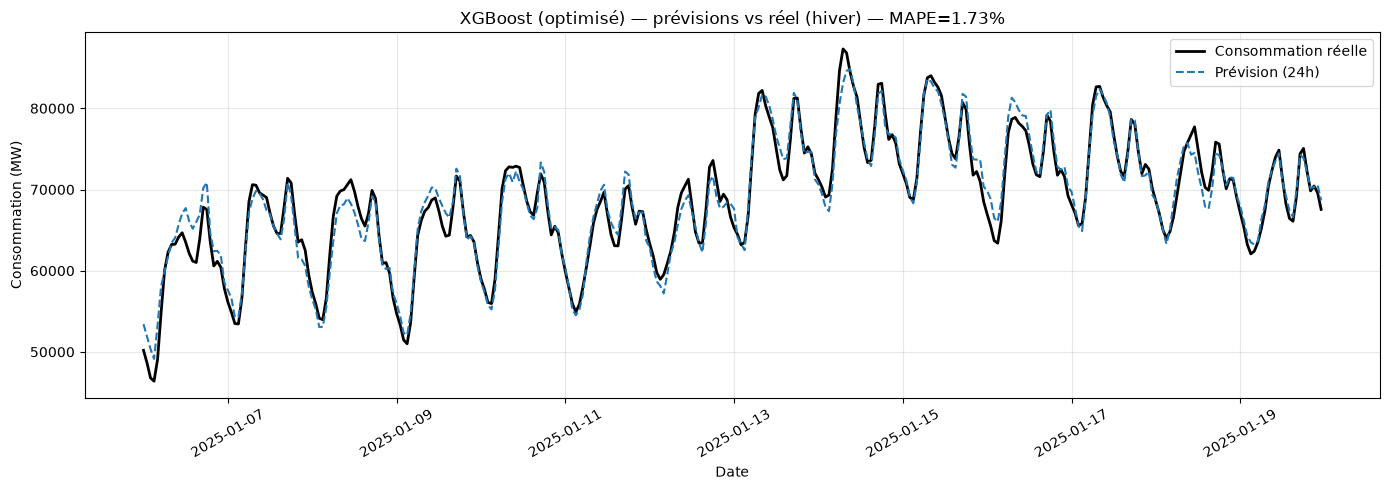

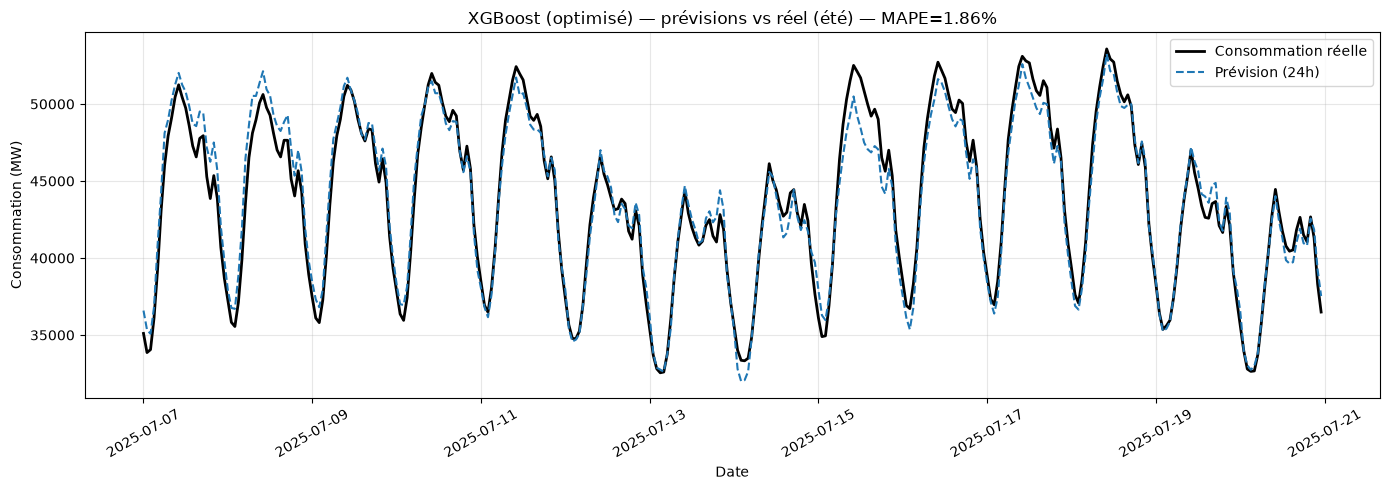

In [22]:
for window_label, (window_start, window_end) in PLOT_WINDOWS.items():
    plot_forecast_vs_actual(
        "XGBoost (optimisé)", window_label, window_start, window_end,
        test_df["target_datetime_utc"], y_test, y_pred_xgb_tuned,
    )


## 14. Comparaison des résultats

In [23]:
comparison_df = pd.DataFrame(results).sort_values("mape").reset_index(drop=True)
comparison_df


,run_name,mape,rmse,mae
0,xgboost,1.771227,1290.031341,916.558069
1,xgboost_tuned,1.774949,1266.813579,913.495266
2,random_forest,2.097003,1571.188143,1086.780854
3,linear_regression,4.172254,2622.171598,2054.715278
4,naive_persistence_baseline,5.104483,3665.277080,2540.238098


## 15. Conclusion

- **Baseline naïve (persistance J-1)** vs **3 modèles** (Régression Linéaire, Random Forest,
  XGBoost, + XGBoost optimisé en 13ter) comparés sur MAPE/RMSE/MAE à horizon fixe 24h, consultable
  dans MLflow (`mlflow ui` depuis la racine du repo, expérience `rte-consumption-forecast`).
  Directement comparable au run `prophet` du notebook `train_timeseries_models.ipynb`, qui évalue
  lui aussi des prévisions à 24h dans la même expérience MLflow.
- **Limitation connue, à garder en tête pour la suite** : `temp_target` utilise la météo **réelle**
  à l'heure cible, pas une prévision archivée — l'évaluation hors-ligne est donc optimiste par
  rapport à un vrai déploiement.
- **Prochaines étapes possibles** : récupération de prévisions météo archivées pour remplacer le
  proxy, conversion du pipeline en script `.py` une fois un modèle choisi.
